## Discussion #4

In this session, we will explore:
- Time series
- Visualization techniques
- APIs

**Files needed:** `none`

**Teaching Assistants:**
- Mitchell Valdes Bobes  
  OH: TR 2:00 - 3:00 | 7308 Social Sciences  
  Email: valdsbobes@wisc.edu
- Robert Remuszka  
  OH: T 1:00 - 2:00 | 7143 Social Sciences  
  Email: remuszka@wisc.edu


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas_datareader.data as web   

# 1. Time Series
**Objective:** Use `groupby` with lambda to aggregate time series data

In [2]:
# Set the seed for reproducibility
np.random.seed(34)
# Create sample daily sales data
dates = pd.date_range('2024-01-01', periods=90, freq='D')
df = pd.DataFrame({
    'date': dates,
    'product': np.random.choice(['A', 'B'], 90),
    'sales': np.random.randint(50, 200, 90)
})
df.set_index('date', inplace=True)
df.head()

,product,sales
date,,
2024-01-01,B,156
2024-01-02,A,63
2024-01-03,A,51
2024-01-04,B,55
2024-01-05,A,149


**Understanding the `rolling()` Function with Datetime**

In pandas, the `rolling()` function lets you apply window-based calculations to time series data. When you pass a datetime offset like `'7D'` to `rolling()`, it defines the window based on time rather than a fixed number of rows.

For example, using:

In [3]:
# Group by product and calculate 7-day moving average
moving_avg = df.groupby('product')["sales"].apply(
    lambda x: x.rolling('7D').mean()
).to_frame()

print("7-Day Moving Average:")
moving_avg

7-Day Moving Average:


sales
product date                  
A       2024-01-02   63.000000
        2024-01-03   57.000000
        2024-01-05   87.666667
        2024-01-07   89.250000
        2024-01-11  121.000000
...                        ...
B       2024-03-18   92.800000
        2024-03-21  116.500000
        2024-03-22  131.250000
        2024-03-23  112.750000
        2024-03-28  118.333333

[90 rows x 1 columns]

**Resample groups the data based on a new date frequency.**

The function `resample()` is used to resample time series data. It groups the data based on a new date frequency. For example, if you have daily data and you want to convert it to monthly data, you can use `resample('ME')` for yearly data, you can use `resample('YE')`, etc.

In [4]:
df.resample('W')["sales"].sum().to_frame()

,sales
date,
2024-01-07,618
2024-01-14,1102
2024-01-21,726
2024-01-28,804
2024-02-04,942
2024-02-11,826
2024-02-18,895
2024-02-25,983
2024-03-03,866


**Exercise (2 mins):**  
Calculate **total monthly sales** per product using the previous dataset.

In [5]:
monthly_sales = df.groupby('product').resample('M').sum()

print("Total Monthly Sales per Product:")
monthly_sales

Total Monthly Sales per Product:


/var/folders/p7/dtlz136x1b5bmnvrgrl428wh0000gn/T/ipykernel_53609/3186952667.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby('product').resample('M').sum()


product  sales
product date                                    
A       2024-01-31         AAAAAAAAAAAAAA   1498
        2024-02-29  AAAAAAAAAAAAAAAAAAAAA   2661
        2024-03-31      AAAAAAAAAAAAAAAAA   2146
B       2024-01-31      BBBBBBBBBBBBBBBBB   2239
        2024-02-29               BBBBBBBB   1089
        2024-03-31          BBBBBBBBBBBBB   1400

# 2. Visualization Techniques (De-junking a Plot)
**Objective:** Use create cleaner visualizations by removing unnecessary elements.

We will be using data on the popularity of different programming languages you can find the survey results [here](http://stackoverflow.com/research/developer-survey-2016#most-popular-technologies-per-occupation).

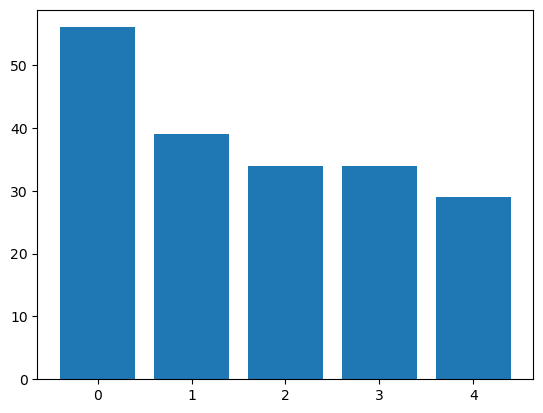

In [6]:
# We have a list of the top 5 programming languages for math and data by popularity on Stack Overflow.
# We want to create a bar chart to visualize the data.
languages =['Python', 'SQL', 'Java', 'C++', 'JavaScript']
# Position of bars on x-axis [0,1,2,3,4]
pos = np.arange(len(languages))
# Popularity value as a percentage of respondents who said they use the language
popularity = [56, 39, 34, 34, 29]

# We start with the most basic bar chart where we only specify the x and y values.
plt.bar(pos, popularity)
plt.show()

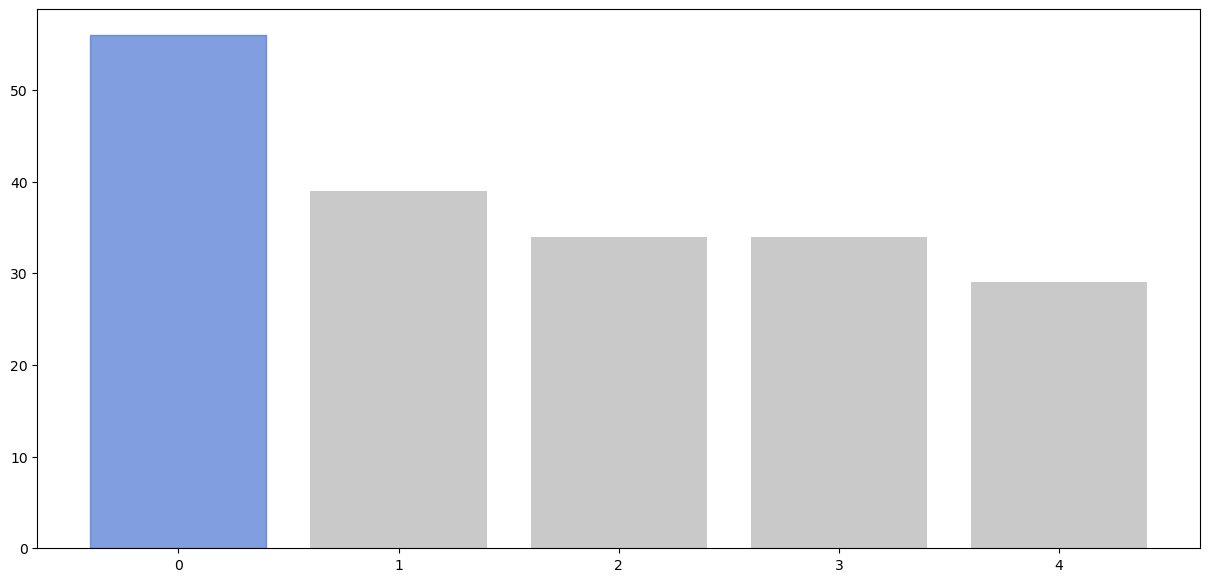

In [7]:
# We can add labels for x and y axis as well as a title for the chart.
# Also let's change the dimensions of the plot to make it more readable.
fig, ax = plt.subplots(1, 1, figsize=(15,7))
# By using align='center' the bars will be centered on the x tick marks.
# Color = '.70' gives the bars a shade of grey and alpha=.7 makes them 30% transparent.
bars = plt.bar(pos, popularity, align='center', color = '.70',alpha=.7)
# We can change a particular bar color by specifying its position.
bars[0].set_color('#4B75D3') # Python blue
plt.show()

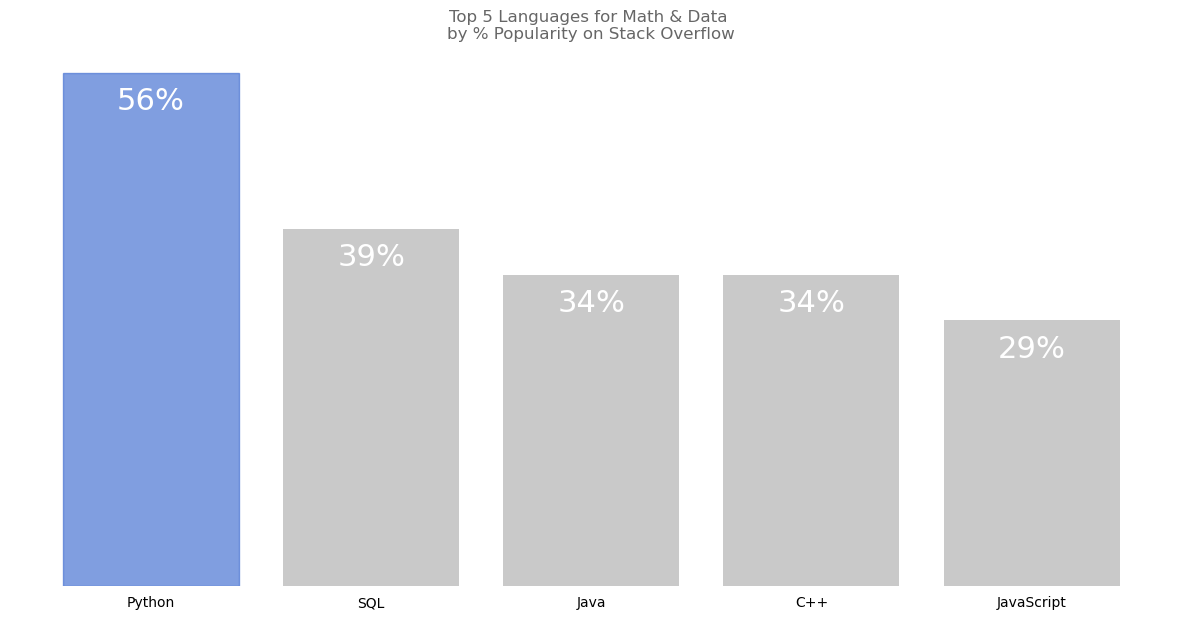

In [8]:
# We can add labels for x and y axis as well as a title for the chart.
# Also let's change the dimensions of the plot to make it more readable.
fig, ax = plt.subplots(1, 1, figsize=(15,7))
# By using align='center' the bars will be centered on the x tick marks.
# Color = '.70' gives the bars a shade of grey and alpha=.7 makes them 30% transparent.
bars = plt.bar(pos, popularity, align='center', color = '.70',alpha=.7)
# We can change a particular bar color by specifying its position.
bars[0].set_color('#4B75D3') # Python blue

# Let's use the programming languages as labels for the x-axis.
plt.xticks(pos, languages)
# Add a title
plt.title('Top 5 Languages for Math & Data \nby % Popularity on Stack Overflow', color='.4')
# Remove the ticks on all sides of the plot
plt.tick_params(top=False, bottom=False, left=False, right=False, labelleft=False, 
                labelbottom=True)
# Remove all spines
for spine in plt.gca().spines.values():
    spine.set_visible(False)
# Finally we can add the data labels on the bars
for bar in bars:
    plt.text(bar.get_x() + (bar.get_width())/2, bar.get_height()-4, str(bar.get_height()) + '%', 
        color = 'w'   , fontsize=22, ha = 'center')
plt.show()

# 3. APIs
**Objective:** Use an API to get data from the web.

In [9]:
apple_stock_data =  web.DataReader('AAPL', 'stooq')
# Filter the data to include only 2024 - to date
apple_stock_data = apple_stock_data.loc[apple_stock_data.index.year >= 2024]

apple_stock_data

,Open,High,Low,Close,Volume
Date,,,,,
2025-10-02,256.575,258.180,254.150,257.130,42630239
2025-10-01,255.040,258.790,254.930,255.450,48713940
2025-09-30,254.855,255.919,253.110,254.630,37704259
2025-09-29,254.560,255.000,253.010,254.430,40127687
2025-09-26,254.095,257.600,253.780,255.460,46076258
...,...,...,...,...,...
2024-01-08,180.999,184.492,180.417,184.453,59499566
2024-01-05,180.904,181.669,179.094,180.099,62754180
2024-01-04,181.064,181.995,179.799,180.824,72415750


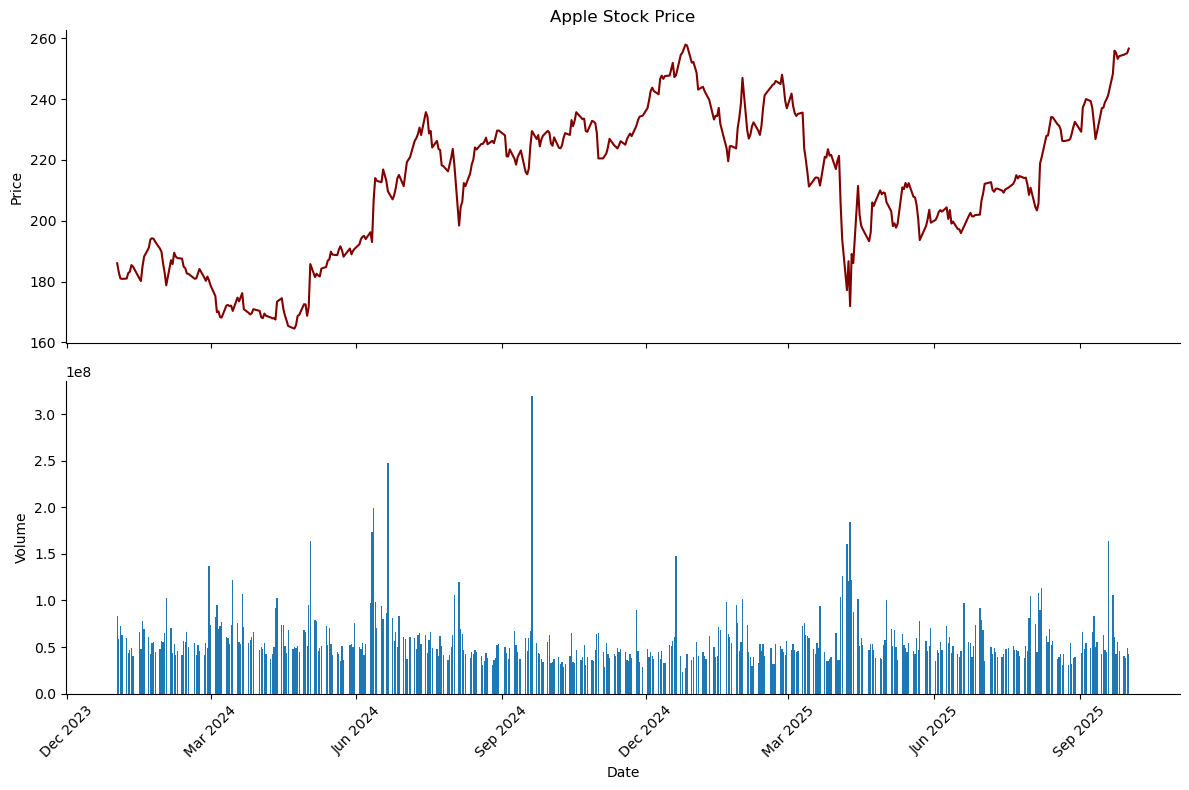

In [10]:
# Create a figure with 2 subplots (stock price on top, volume on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top plot: Stock price (Open)
ax1.plot(apple_stock_data.index, apple_stock_data['Open'], color='maroon')
ax1.set_title('Apple Stock Price')
ax1.set_ylabel('Price')


# Bottom plot: Volume as bar plot
ax2.bar(apple_stock_data.index, apple_stock_data['Volume'])#, color='grey', alpha=0.7)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')


# Customize x-axis for both plots (only bottom displays labels)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

**Exercise (Long):**  
Using the previous knowledge, customize the plot further, create a function that takes the following arguments:
- `symbol`: The stock symbol to plot
- `window_size`: The window size for the moving mean
Your function should return a plot with a smoothed **Close** price of the stock smoothed with a rolling mean of `window_size` days. The plot should have the following characteristics:
- **Title:** "<Symbol> Stock Price"
- **X-axis:** "Date"
- **Y-axis:** "Price"
- **Date Format:** "Apr 2020" with ticks every 2 months
- **Rotation:** 45 degrees for x-axis labels

In [16]:
def plot_smoothed_stock(symbol, window_size):
    # Fetch data
    data = web.DataReader(symbol, 'stooq')
    data = data.loc[data.index.year >= 2024]
    smoothed = data['Close'].rolling(window=window_size).mean()
    fig, ax = plt.subplots(figsize=(12,6))
    ax.plot(data.index, smoothed, color='navy')
    ax.set_title(f"{symbol} Stock Price")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.xticks(rotation=45)
    sns.despine()
    plt.tight_layout()
    plt.show()

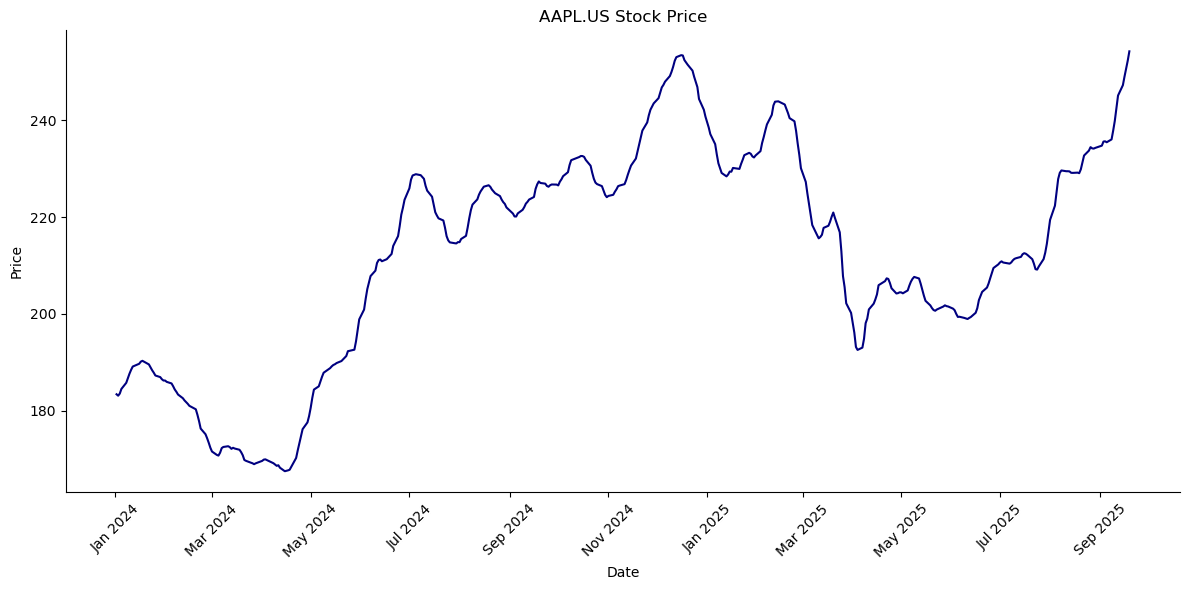

In [18]:
plot_smoothed_stock("AAPL.US", 10)  # stooq needs the “.US” suffix for U.S. tickers
